# Parameter calibration based on polarization test data — dynamic model

This notebook calibrates the undetermined physical parameters of the 1D static PEMFC model by fitting the simulated cell voltage to experimental measurements across 12 operating conditions (temperature, pressure, humidity).

In [1]:
import sys
import math
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folder
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from config.settings import *
from model.dynamic import PEMFC_dyn
from model.coefficients import *
from config.initialize import *
from modules.tests import *

## Calibration setup

### Simulation setup
This step determines the accuracy and efficiency of the optimizer. Increasing the current point may increase the accuracy but definitely reduce the efficiency.

In [3]:
I_tested = [10, 30, 40, 45, 50]
RHC_tested = [0, 50]
PAC_tested = [1.3e5,1.4e5,1.5e5]
TFC_tested = [50, 60, 70]

### Experiment data import

In [4]:
exp_pola_data = pd.ExcelFile(project_root / "data" / "Polar_curves.xlsx")
polardata_exp = {sname: pd.read_excel(exp_pola_data, sheet_name=sname) for sname in exp_pola_data.sheet_names}

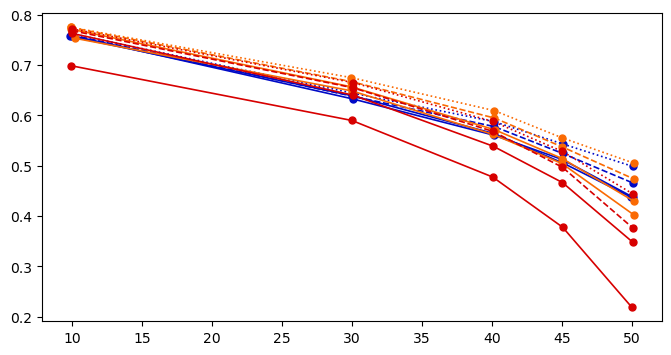

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

for name, data in polardata_exp.items():
    i_values = data["I_LOAD"].to_numpy(dtype=float)
    v_values = data["VFC"].to_numpy(dtype=float) / n_cell
    idx_extracted = []
    for i_test in I_tested:
        idx_extracted.append(np.argmin((i_test - i_values) ** 2))
    plot_condition(ax, i_values[idx_extracted], v_values[idx_extracted], name, linewidth=1.2, markersize=5)

### Setup the simulation for all wanted conditions

In [6]:
def polartest_sim(model_calib):
    """Run the dynamic model across every (RHC, P, T) condition for which we
    have experimental data and return ``{cond_key: [Ucell at I_tested]}``.
    Returns ``False`` if any cell voltage came back NaN.

    Uses ``model_calib.parameters`` / ``model_calib.operating_inputs``
    consistently -- never the imported globals -- so concurrent trials with
    different parameters cannot race on the same dict.
    """
    OCV = model_calib.parameters["OCV"]
    Aact = model_calib.parameters["Aact"]
    op = model_calib.operating_inputs

    result = {}
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des/1e2 - 1e3)) + "_HRC" + str(RHC)
                if cond_key not in polardata_exp:
                    continue
                op["Phi_c_des"] = RHC / 100
                op["Pa_des"] = P_des
                op["Pc_des"] = P_des
                op["Tfc"]    = T_des + 273.15

                Ucell_test = []
                for I_LOAD in I_tested:
                    # Default-arg captures the current density by value so the
                    # lambda is not tied to the loop variable I_LOAD.
                    i_density = I_LOAD / Aact
                    op["current_density"] = lambda t, _i=i_density: _i

                    x_init = init_x(op, model_calib.parameters)
                    sol = solve_ivp(model_calib.dxdt, (0, 60), x_init,
                                    method="BDF", max_step=1e-1)
                    last = {k: sol.y[idx, -1] for idx, k in enumerate(model_calib.solver_variable_names)}

                    Rmem_t, Rccl_t, Racl_t = Rproton(last, model_calib.parameters)
                    Rp = sum(Rmem_t) + Rccl_t + Racl_t
                    Ueq_t = Ueq(last)
                    Ucell_test.append(Ueq_t - OCV
                                      - i_density * (Rp + model_calib.parameters["Re"])
                                      - last["eta_c"])
                    if any(math.isnan(v) for v in Ucell_test):
                        return False

                result[cond_key] = Ucell_test
    return result


In [7]:
from copy import deepcopy

def _experimental_ucell(cond_key):
    """Look up the experimental cell voltage at every I_tested for one
    operating condition. Picks the closest sample from the polar curve
    DataFrame and divides by ``n_cell`` (full-stack -> per-cell)."""
    df = polardata_exp[cond_key]
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / n_cell
    idx = [np.argmin((i_test - i_exp) ** 2) for i_test in I_tested]
    return v_exp[idx]


def objective(trial):
    # Per-trial copies of the imported globals -- critical when
    # study.optimize uses n_jobs > 1, otherwise concurrent trials race
    # on the same `parameters` and `operating_inputs` dicts.
    params_trial = deepcopy(parameters)
    op_trial     = deepcopy(operating_inputs)

    params_trial["OCV"]          = trial.suggest_float("OCV",          0.2,   0.4,  log=True)
    params_trial["i0_c_ref"]     = trial.suggest_float("i0_c_ref",     1e-2,  10,   log=True)
    params_trial["kappa_c"]      = trial.suggest_float("kappa_c",      1,     10,   log=True)
    params_trial["tau"]          = trial.suggest_float("tau",          1,     4,    log=True)
    params_trial["Re"]           = trial.suggest_float("Re",           1e-7,  1e-5, log=True)
    params_trial["epsilon_mc"]   = trial.suggest_float("epsilon_mc",   0.15,  0.4,  log=True)
    params_trial["epsilon_gdl"]  = trial.suggest_float("epsilon_gdl",  0.5,   0.7,  log=True)
    params_trial["epsilon_c"]    = trial.suggest_float("epsilon_c",    0.1,   0.3,  log=True)
    params_trial["epsilon_cl"]   = trial.suggest_float("epsilon_cl",   0.1,   0.4,  log=True)
    params_trial["a_slim"]       = trial.suggest_float("a_slim",       1e-2,  0.5,  log=True)
    params_trial["b_slim"]       = trial.suggest_float("b_slim",       1e-2,  0.5,  log=True)
    params_trial["a_switch"]     = trial.suggest_float("a_switch",     1e-2,  0.5,  log=True)
    params_trial["Hcl"]          = trial.suggest_float("Hcl",          1e-5,  2e-5, log=True)
    params_trial["Hgdl"]         = trial.suggest_float("Hgdl",         2e-5,  5e-5, log=True)

    model_trial = PEMFC_dyn(params_trial, op_trial, init_x(op_trial, params_trial))

    try:
        polardata_sim = polartest_sim(model_trial)
    except Exception:
        return 100.0
    if polardata_sim is False:
        return 100.0

    # Sum of squared residuals across all conditions.
    error_sum = 0.0
    for cond_key, ucell_sim in polardata_sim.items():
        ucell_exp = _experimental_ucell(cond_key)
        error_sum += float(np.sum((np.array(ucell_sim) - ucell_exp) ** 2))

    return error_sum


In [8]:
import optuna
from optuna.pruners import MedianPruner

# Each trial runs ~30 short BDF integrations (one per (T, P, RH, I) point
# present in the experimental dataset). Budget your wall-time and tweak
# n_trials / timeout / n_jobs accordingly. The objective above creates
# its own copies of `parameters` and `operating_inputs`, so n_jobs > 1
# is safe.
study = optuna.create_study(direction="minimize", pruner=MedianPruner())
study.optimize(objective, n_trials=300, timeout=600, n_jobs=6)

print("Best parameters:", study.best_params)
print("Best objective:", study.best_value)


[I 2026-05-06 01:44:44,586] A new study created in memory with name: no-name-91be6d16-cf79-49b6-9e67-f8ce962f587a
[I 2026-05-06 02:14:21,742] Trial 1 finished with value: 356.62284187760076 and parameters: {'OCV': 0.22164237368132536, 'i0_c_ref': 0.08848118205123834, 'kappa_c': 2.7863434061980152, 'tau': 1.9762897271936042, 'Re': 3.6136397607251536e-06, 'epsilon_mc': 0.1751576744931733, 'epsilon_gdl': 0.6101613595577431, 'epsilon_c': 0.28637631371370476, 'epsilon_cl': 0.21175299228136196, 'a_slim': 0.4144150661507656, 'b_slim': 0.3461036160846393, 'a_switch': 0.16009011063666687, 'Hcl': 1.1483452119727792e-05, 'Hgdl': 2.295012887874974e-05}. Best is trial 1 with value: 356.62284187760076.
[I 2026-05-06 02:15:02,519] Trial 2 finished with value: 1079.0639946789224 and parameters: {'OCV': 0.271830363841988, 'i0_c_ref': 0.05432913229920829, 'kappa_c': 4.401532495879544, 'tau': 2.1479723238015733, 'Re': 4.167946673005309e-06, 'epsilon_mc': 0.16720164216034406, 'epsilon_gdl': 0.668304739346

Best parameters: {'OCV': 0.326519995289051, 'i0_c_ref': 0.10242476429628304, 'kappa_c': 4.97192482496723, 'tau': 1.4051046501597002, 'Re': 2.209619990176595e-06, 'epsilon_mc': 0.20212679039299083, 'epsilon_gdl': 0.579225665778844, 'epsilon_c': 0.13365902394544607, 'epsilon_cl': 0.17735627543446936, 'a_slim': 0.032925387878614674, 'b_slim': 0.33899765499915024, 'a_switch': 0.047528644953808735, 'Hcl': 1.416920395290936e-05, 'Hgdl': 2.4178499590087213e-05}
Best objective: 44.88574968146053


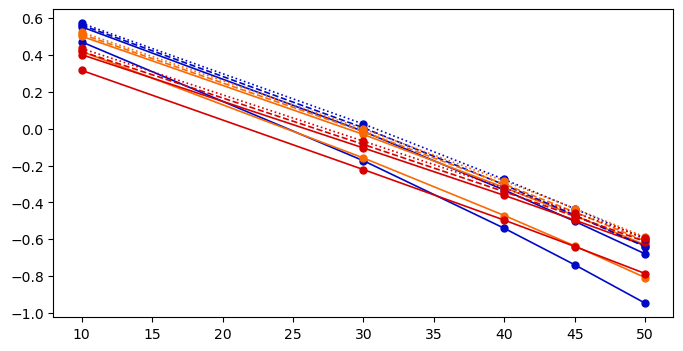

In [9]:
for key, value in study.best_params.items():
    parameters[key] = value
model = PEMFC_dyn(parameters,operating_inputs, init_x(operating_inputs, parameters))
polardata_sim = polartest_sim(model)
fig, ax = plt.subplots(figsize=(8, 4))
for name, data in polardata_sim.items():
    plot_condition(ax, I_tested, data, name, linewidth=1.2, markersize=5)